# Clustering: Analysis and Selection of the Optimal Model

[KMEANS] Silhouette Score: 0.515 | Davies-Bouldin Index: 0.708


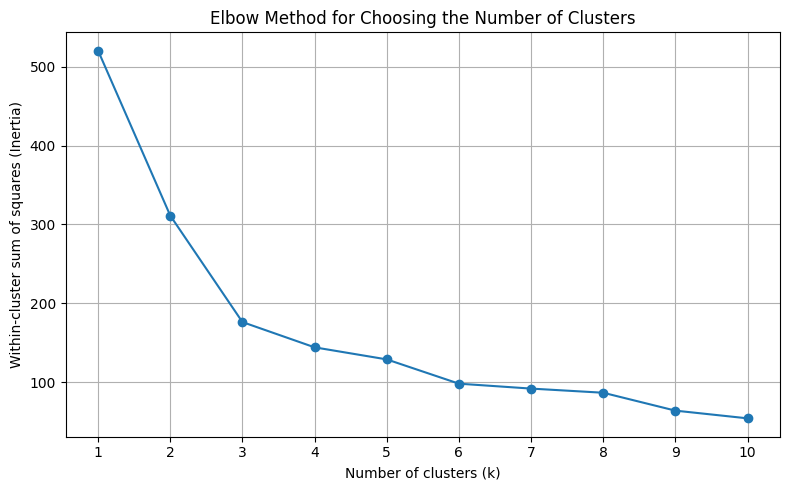

[AGGLOMERATIVE] Silhouette Score: 0.493 | Davies-Bouldin Index: 0.745


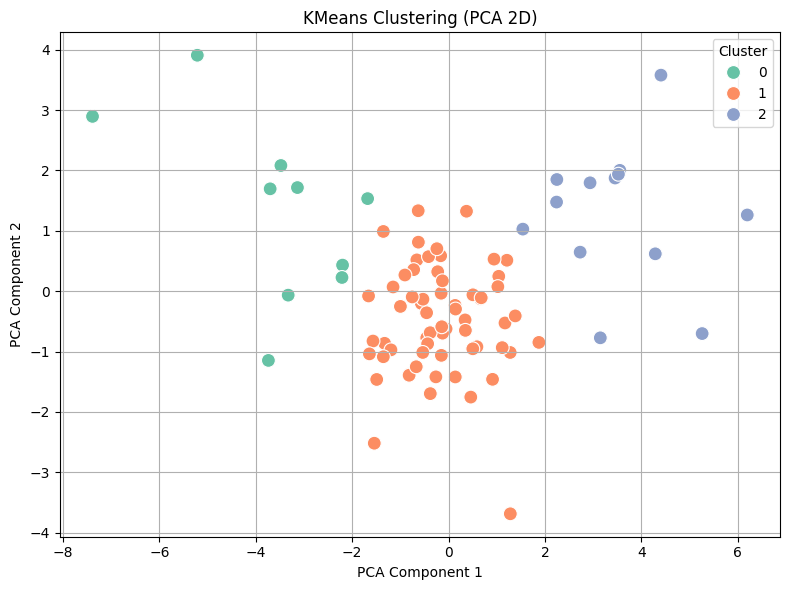

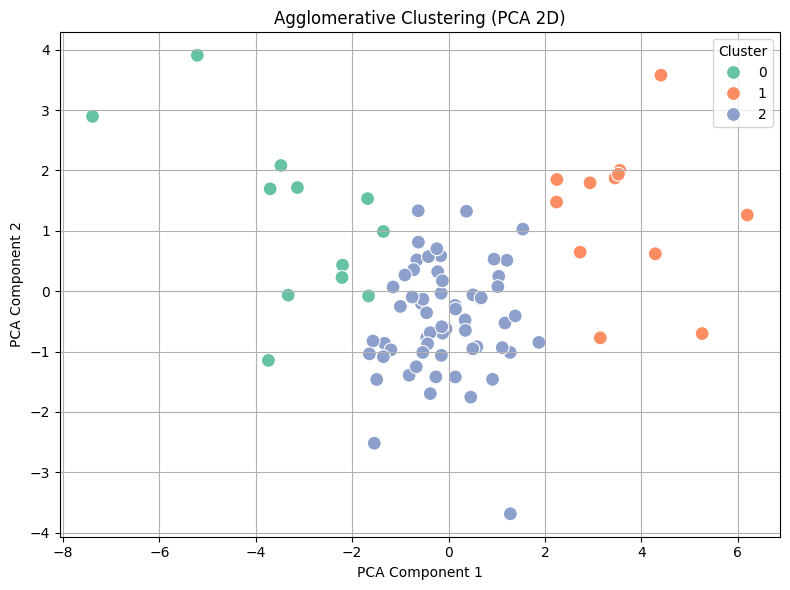


=== Regions by clusters: KMEANS_CLUSTER ===

Cluster 0 — 10 regions:
Республика Калмыкия, Республика Крым, Республика Дагестан, Республика Ингушетия, Кабардино-Балкарская Республика, Карачаево-Черкесская Республика, Чеченская Республика, Ставропольский край, Республика Алтай, Республика Тыва

Cluster 1 — 62 regions:
Белгородская область, Брянская область, Владимирская область, Воронежская область, Ивановская область, Калужская область, Костромская область, Курская область, Липецкая область, Орловская область, Рязанская область, Смоленская область, Тамбовская область, Тверская область, Тульская область, Ярославская область, Республика Карелия, Республика Коми, Архангельская область, Вологодская область, Калининградская область, Ленинградская область, Новгородская область, Псковская область, Санкт-Петербург, Республика Адыгея, Краснодарский край, Астраханская область, Волгоградская область, Ростовская область, Севастополь, Республика Северная Осетия - Алания, Республика Башкортостан, Ре

In [4]:
# Import libraries
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns

# --- Load data ---
df_full = pd.read_csv("../../data/clean/log_master_dataset_2015_2020.csv")
df = df_full.drop_duplicates(subset=["region"], keep="last").reset_index(drop=True)

# --- Select features ---
features = [
    'log_income_per_capita',
    'log_production_per_capita',
    'log_birth_rate_per_1000',
    'welfare_percent',
    'dependent_percent',
    'log_disabled_rate_per_1000',
    'log_gdp_per_capita',
    'log_retail_per_capita',
    'log_addiction_rate',
    'log_infant_mortality_urban_rate',
    'log_infant_mortality_rural_rate'
]

# --- Scaling ---
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])

# --- PCA ---
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# --- KMeans ---
kmeans = KMeans(n_clusters=3, random_state=42)
df['kmeans_cluster'] = kmeans.fit_predict(X_pca)
sil_k = silhouette_score(X_pca, df['kmeans_cluster'])
dbi_k = davies_bouldin_score(X_pca, df['kmeans_cluster'])
print(f"[KMEANS] Silhouette Score: {sil_k:.3f} | Davies-Bouldin Index: {dbi_k:.3f}")

# --- Elbow method ---
inertia = []
k_range = range(1, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_pca)
    inertia.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method for Choosing the Number of Clusters")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Within-cluster sum of squares (Inertia)")
plt.grid(True)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

# --- Agglomerative ---
agglo = AgglomerativeClustering(n_clusters=3)
df['agglo_cluster'] = agglo.fit_predict(X_pca)
sil_a = silhouette_score(X_pca, df['agglo_cluster'])
dbi_a = davies_bouldin_score(X_pca, df['agglo_cluster'])
print(f"[AGGLOMERATIVE] Silhouette Score: {sil_a:.3f} | Davies-Bouldin Index: {dbi_a:.3f}")

# --- KMeans visualization ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['kmeans_cluster'], palette="Set2", s=100)
plt.title("KMeans Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

# --- Agglomerative visualization ---
plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df['agglo_cluster'], palette="Set2", s=100)
plt.title("Agglomerative Clustering (PCA 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.grid(True)
plt.legend(title="Cluster")
plt.tight_layout()
plt.show()

def print_cluster_regions(cluster_col_name):
    print(f"\n=== Regions by clusters: {cluster_col_name.upper()} ===")
    clusters = df.groupby(cluster_col_name)['region'].apply(list)
    for cluster_id, region_list in clusters.items():
        print(f"\nCluster {cluster_id} — {len(region_list)} regions:")
        print(", ".join(region_list))  # all regions in one line

print_cluster_regions('kmeans_cluster')
print_cluster_regions('agglo_cluster')

### Clustering Methods Summary

In this analysis, multiple clustering approaches were tested to identify socially vulnerable regions and factors associated with poverty.  
We conducted a targeted experimental feature selection, tuned the number of clusters, and applied several clustering algorithms, namely:

- **KMeans**
- **Agglomerative Clustering**

Dimensionality reduction using **PCA (2 components)** was also applied to improve clustering quality, reduce multicollinearity, and enhance interpretability.

We explored:
- different **feature sets**, selecting only those that are logically justified and non-redundant;
- varying **numbers of clusters**, guided by both quality metrics and interpretability;
- the analysis was performed **only on the most recent available year (2020)**, as it reflects the **current socio-economic state of regions**.

Importantly, the **final clustering was performed without the `poverty_percent` feature**. This was done intentionally to:
- avoid introducing bias by directly including the poverty indicator;
- focus on **factors influencing poverty**, rather than poverty itself;
- later use `poverty_percent` to analyze **differences within the formed clusters**, which aligns with the project objectives.

To evaluate clustering quality, we used:
- **Silhouette Score**
- **Davies-Bouldin Index**

The best results were achieved with **KMeans + PCA (2 components)** using 3 clusters:
- Silhouette Score = **0.515**
- Davies-Bouldin Index = **0.708**

The **Agglomerative Clustering** method showed comparable performance:
- Silhouette Score = **0.493**
- Davies-Bouldin Index = **0.745**

Both methods revealed a stable structure in the data.  
Overall, a comprehensive methodology was implemented, including feature selection, parameter tuning, application of multiple algorithms, and comparative evaluation of results.

In [5]:
# Add cluster labels based on df (where regions are already labeled)
region_clusters = df[["region", "agglo_cluster"]].copy()
df_full = df_full.merge(region_clusters, on="region", how="left")

# Save to CSV
df_full.to_csv("../../data/clean/df_clusters.csv", index=False)
df_full[["region", "year", "agglo_cluster"]].to_csv("../../data/clean/region_clusters.csv", index=False)